## Loading of Stringer spontaneous data

includes some visualizations

In [ ]:
# @title Install dependencies
!pip install umap-learn --quiet

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# from umap import UMAP
from scipy.ndimage import uniform_filter1d
from scipy.stats import zscore
from sklearn.decomposition import PCA

In [ ]:
# @title Figure settings
from matplotlib import rcParams

rcParams['figure.figsize'] = [20, 4]
rcParams['font.size'] =15
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['figure.autolayout'] = True

In [ ]:
# @title Data retrieval
import os, requests

fname = "stringer_spontaneous.npy"
url = "https://osf.io/dpqaj/download"

if not os.path.isfile(fname):
  try:
    r = requests.get(url)
  except requests.ConnectionError:
    print("!!! Failed to download data !!!")
  else:
    if r.status_code != requests.codes.ok:
      print("!!! Failed to download data !!!")
    else:
      with open(fname, "wb") as fid:
        fid.write(r.content)

In [ ]:
# @title Data loading

dat = np.load('stringer_spontaneous.npy', allow_pickle=True).item()
print(dat.keys())

dict_keys(['sresp', 'run', 'beh_svd_time', 'beh_svd_mask', 'stat', 'pupilArea', 'pupilCOM', 'xyz'])


dat has fields:
* `dat['sresp']`: neurons by timebins, a.k.a. the neural response data (11983 by 7018). Timebin = 1.2 sec.
* `dat['run']`: timebins by 1, a.k.a. the running speed of the animal in a.u.
* `dat['xyz']`: three-dimensional position of each neuron in the brain.
* `dat['pupilArea']`: timebins by 1, see FaceMap for details on the pupil tracker
* `dat['pupilCOM']`: timebins by 2, correspond to X and Y position. See FaceMap for details on the pupil tracker.
* `dat['beh_svd_time']`: timebins by 1,000. Timecourses of behavioral SVDs extracted from face movies. See FaceMap for details.
* `dat['beh_svd_mask']`: 240 by 320 by 1,000. Spatial masks of behavioral SVDs. Roughly normalized to each other.
* `dat['beh_svd_mask'] @ dat['beh_svd_time'][T, :]`:  reconstruction of the face movie (its motion energy) for frame T
* `dat['stat']`: 1 by neurons, some statistics for each neuron, see Suite2p for full documentation.

In [ ]:
print(dat['sresp'].shape)
print(len(dat['stat']))

(11983, 7018)
11983


In [ ]:
print(dat['run'].shape)

(7018, 1)


/tmp/ipython-input-1627216238.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('jet')(xc)


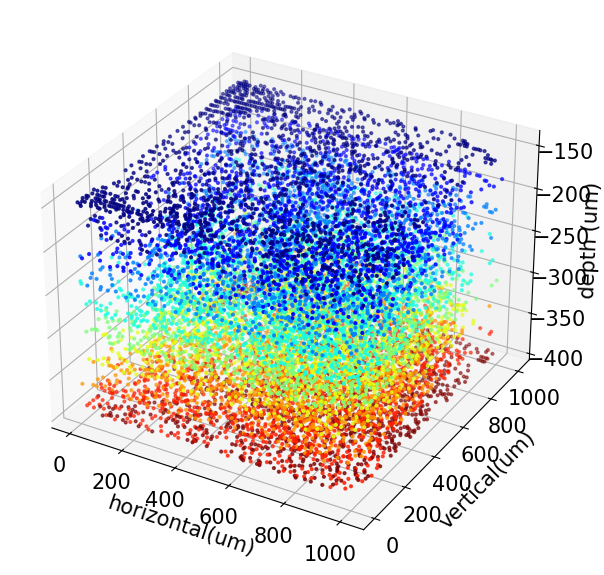

In [ ]:
# @title plot the 3D positions of all neurons
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

x, y, z = dat['xyz']

zunq, iunq = np.unique(z, return_inverse=True)
xc = np.linspace(0.0, 1.0, len(zunq))
cmap = cm.get_cmap('jet')(xc)

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x[::-1],y[::-1], z[::-1], 'o', s=4, c=cmap[iunq])
ax.set(xlabel='horizontal(um)', ylabel='vertical(um)', zlabel='depth (um)')
plt.show()

copmute R^2 for different depths, use colours as an indication for accuracy
use slices of depths and divide it into four qudrants

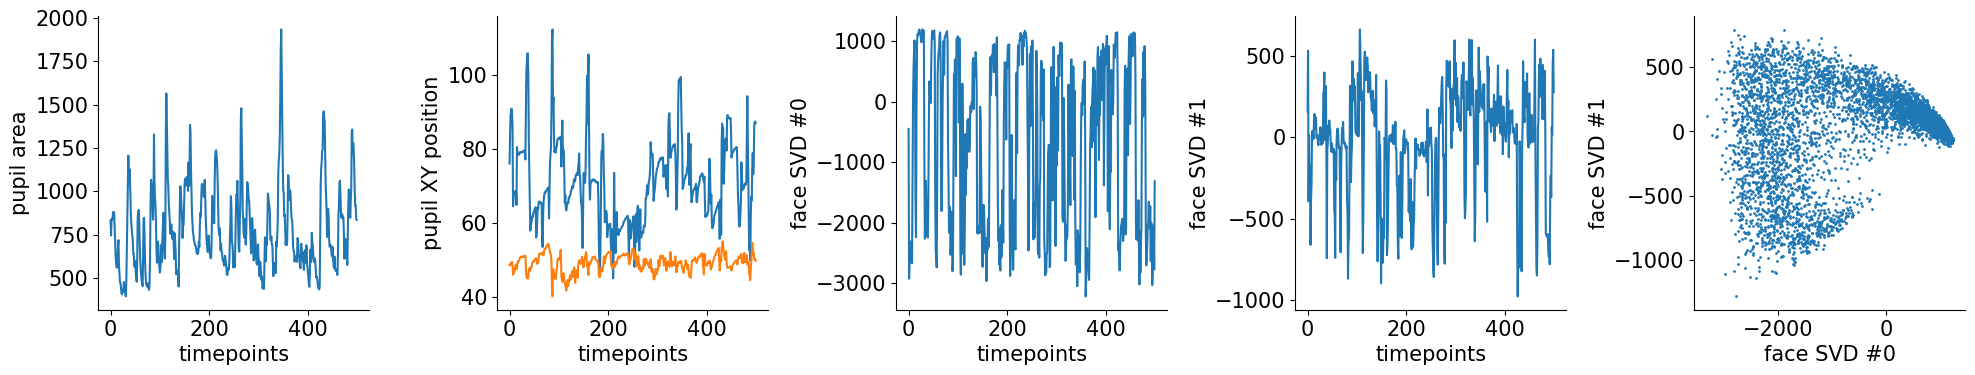

In [ ]:
# @title Basic properties of behavioral data using plot and scatter
ax = plt.subplot(1, 5, 1)
plt.plot(dat['pupilArea'][:500, 0])
ax.set(xlabel='timepoints', ylabel='pupil area')

ax = plt.subplot(1, 5, 2)
plt.plot(dat['pupilCOM'][:500, :])
ax.set(xlabel='timepoints', ylabel='pupil XY position')

ax = plt.subplot(1, 5, 3)
plt.plot(dat['beh_svd_time'][:500, 0])
ax.set(xlabel='timepoints', ylabel='face SVD #0')

ax = plt.subplot(1, 5, 4)
plt.plot(dat['beh_svd_time'][:500, 1])
ax.set(xlabel='timepoints', ylabel='face SVD #1')

ax = plt.subplot(1, 5, 5)
plt.scatter(dat['beh_svd_time'][:, 0], dat['beh_svd_time'][:, 1], s=1)
ax.set(xlabel='face SVD #0', ylabel='face SVD #1')

plt.show()

In [ ]:
# @title take PCA after preparing data by z-score

Z = zscore(dat['sresp'], axis=1)
Z = np.nan_to_num(Z)
X = PCA(n_components=200).fit_transform(Z)

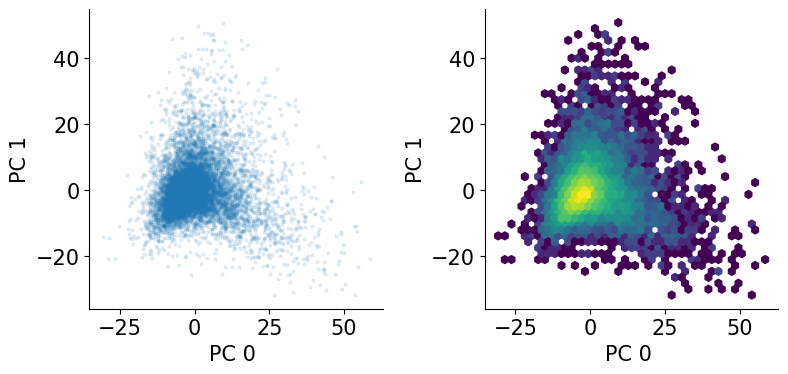

In [ ]:
# @title Plot PCs. Too many points, switch to logarithmic hexbin!
ax = plt.subplot(1, 5, 1)
plt.scatter(X[:, 0], X[:, 1], s=4, alpha=.1)
ax.set(xlabel='PC 0 ', ylabel='PC 1')

ax = plt.subplot(1, 5, 2)
plt.hexbin(X[:, 0], X[:, 1], gridsize=40, bins='log')
ax.set(xlabel='PC 0 ', ylabel='PC 1', alpha=.1)

plt.show()

In [ ]:
# @title run a manifold embedding algorithm (UMAP) in two or three dimensions.
from umap import UMAP

ncomp = 1 # try 2, then try 3
xinit = 1 * zscore(X[:, :ncomp], axis=0)
embed = UMAP(n_components=ncomp, init=xinit, n_neighbors=20,
             metric='correlation', transform_seed=42).fit_transform(X)

In [ ]:
embed = embed.flatten()
isort = np.argsort(embed)
RasterMap = uniform_filter1d(Z[isort, :], size=50, axis=0)
RasterMap = zscore(RasterMap[::10, :], axis=1)

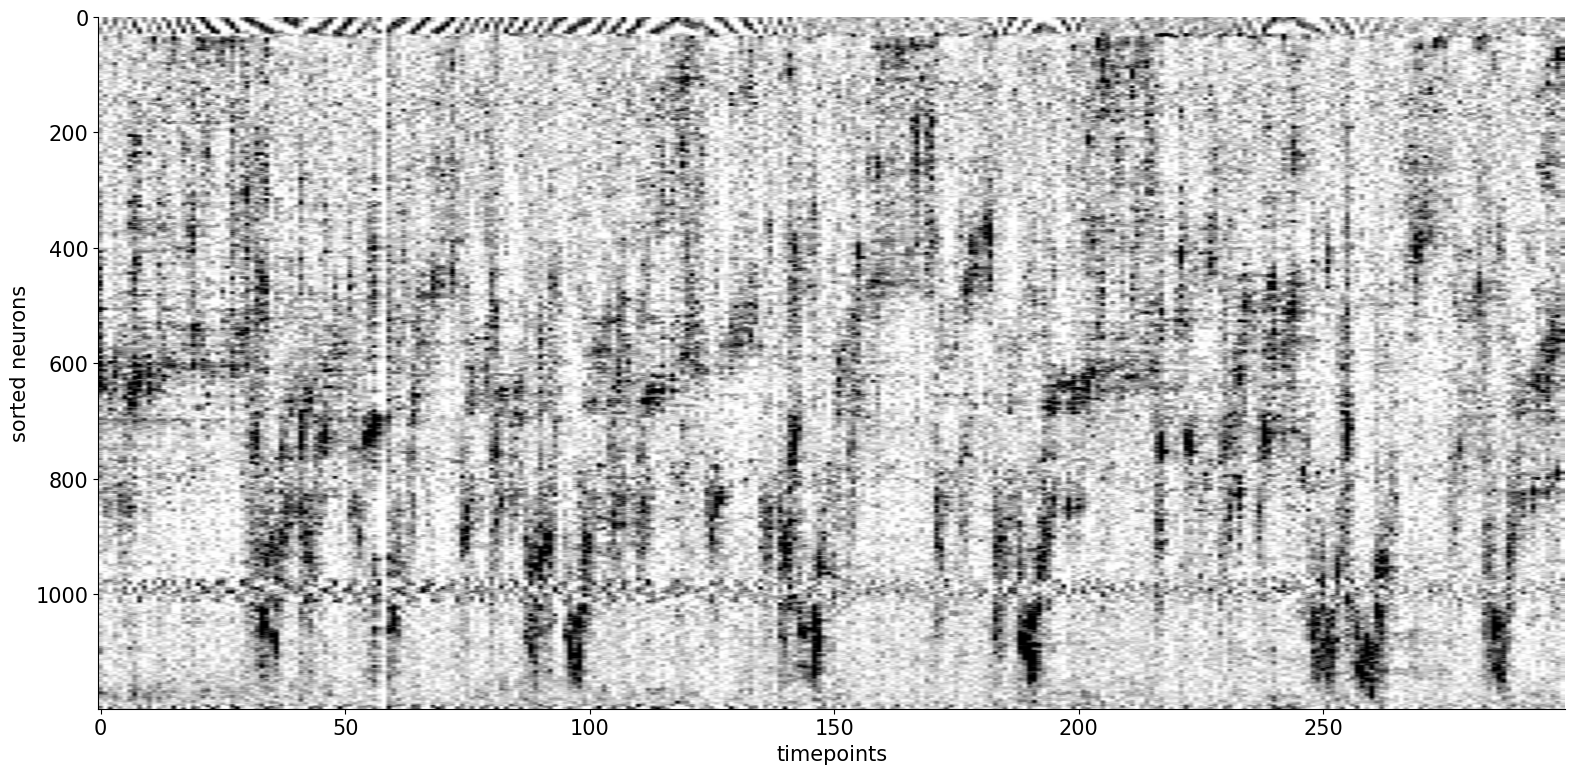

In [ ]:
plt.figure(figsize=(16, 8))
ax = plt.subplot(111)
trange = np.arange(1100, 1400)
plt.imshow(RasterMap[:, trange], vmax= 3, vmin=-1, aspect='auto', cmap='gray_r')
ax.set(xlabel='timepoints', ylabel='sorted neurons')
plt.show()

In [ ]:
# now sort with UMAP both the neuron axis and the timepoints axis, bin the sorted matrix and make a sorted Rastermap picture

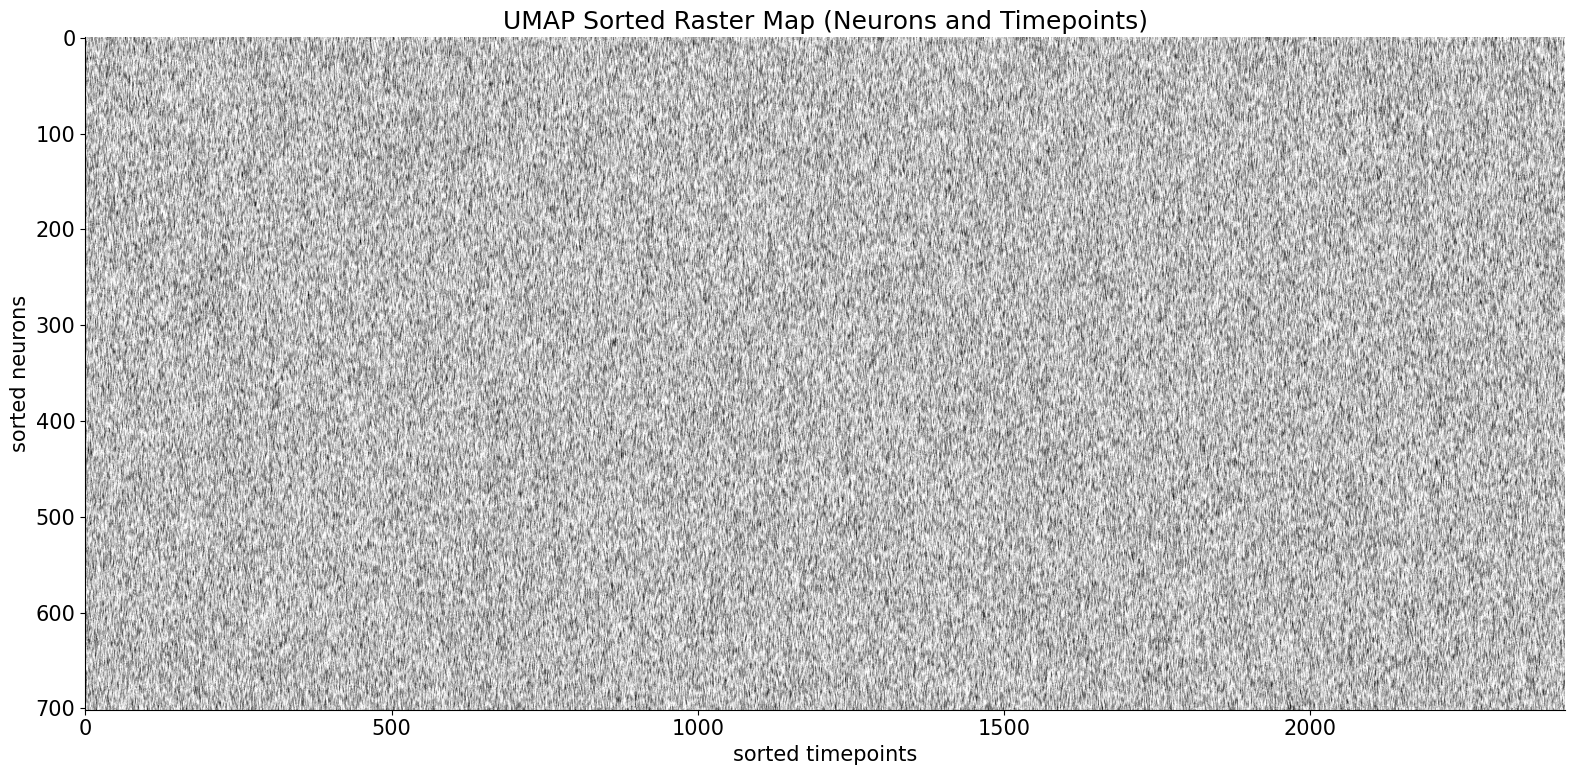

In [ ]:
# @title Sort with UMAP both the neuron axis and the timepoints axis, bin the sorted matrix and make a sorted Rastermap picture
from umap import UMAP
from sklearn.decomposition import PCA
from scipy.ndimage import uniform_filter1d
from scipy.stats import zscore
import matplotlib.pyplot as plt
import numpy as np

# Ensure Z is available from previous steps. If not, re-create it.
# Z = zscore(dat['sresp'], axis=1)
# Z = np.nan_to_num(Z)

# UMAP for neuron axis (neurons by components)
# X was previously defined as PCA(n_components=200).fit_transform(Z)
# Let's ensure X is correctly representing neurons by components
X_neurons = PCA(n_components=200).fit_transform(Z) # Z is (neurons, timebins)

ncomp_neurons = 1
xinit_neurons = 1 * zscore(X_neurons[:, :ncomp_neurons], axis=0)
embed_neurons = UMAP(n_components=ncomp_neurons, init=xinit_neurons, n_neighbors=50, # Changed from 10 to 50
                     metric='correlation', transform_seed=42).fit_transform(X_neurons)
isort_neurons = np.argsort(embed_neurons.flatten())

# UMAP for timepoints axis (timebins by components)
Z_timepoints = Z.T # Transpose Z to get (timebins, neurons)
X_timepoints = PCA(n_components=200).fit_transform(Z_timepoints)

ncomp_timepoints = 1
xinit_timepoints = 1 * zscore(X_timepoints[:, :ncomp_timepoints], axis=0)
embed_timepoints = UMAP(n_components=ncomp_timepoints, init=xinit_timepoints, n_neighbors=50, # Changed from 10 to 50
                        metric='correlation', transform_seed=42).fit_transform(X_timepoints)
isort_timepoints = np.argsort(embed_timepoints.flatten())

# Create a new RasterMap sorted by both neuron and timepoint axes
SortedRasterMap = Z[isort_neurons, :][:, isort_timepoints]

# Smooth and z-score the new RasterMap
SmoothedSortedRasterMap = uniform_filter1d(SortedRasterMap, size=50, axis=0)
FinalRasterMap = zscore(SmoothedSortedRasterMap[::10, :], axis=1)

# Plot the new sorted RasterMap
plt.figure(figsize=(16, 8))
ax = plt.subplot(111)
# Adjust trange if needed, or plot the entire map
plt.imshow(FinalRasterMap, vmax=3, vmin=-1, aspect='auto', cmap='gray_r')
ax.set(xlabel='sorted timepoints', ylabel='sorted neurons')
plt.title('UMAP Sorted Raster Map (Neurons and Timepoints)')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

0.0 57.55417351414499 3.9668140969962598


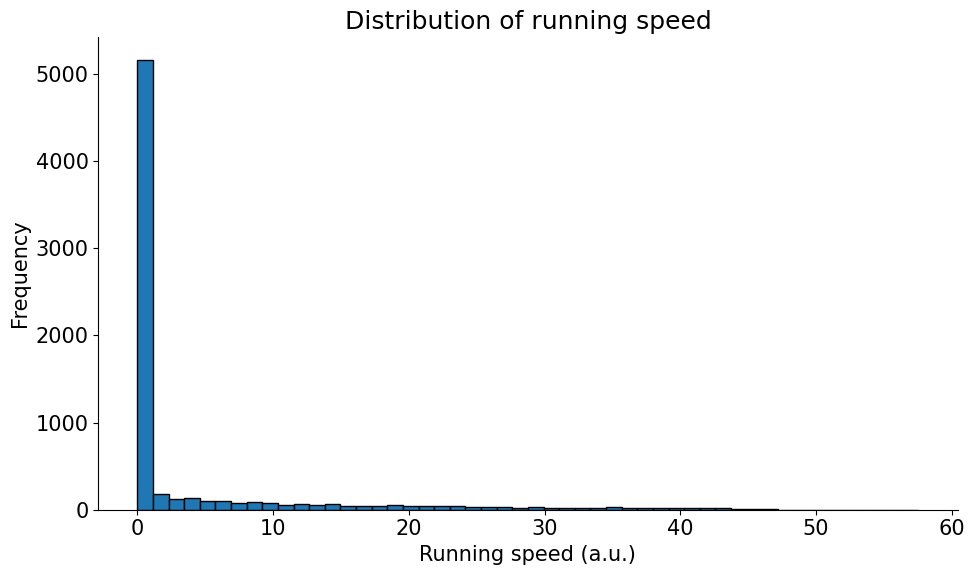

In [ ]:
run_data = dat['run']

min_speed = np.min(run_data)
max_speed = np.max(run_data)
mean_speed = np.mean(run_data)
median_speed = np.median(run_data)
std_speed = np.std(run_data)

plt.figure(figsize=(10, 6))
plt.hist(run_data, bins=50, edgecolor='black')
plt.title('Distribution of running speed')
plt.xlabel('Running speed (a.u.)')
plt.ylabel('Frequency')

print(min_speed, max_speed, mean_speed)

In [ ]:
X = dat['sresp'].T
y= dat['run']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

Mean Squared Error: 23.56
R-squared: 0.69


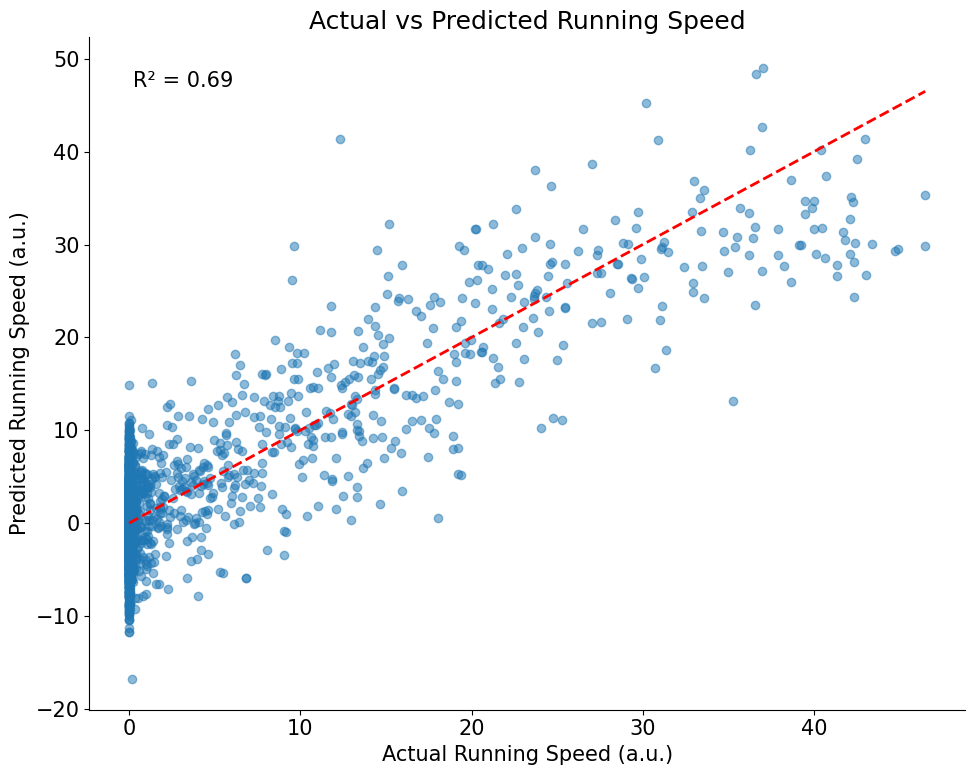

In [ ]:
# Create the scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.xlabel('Actual Running Speed (a.u.)')
plt.ylabel('Predicted Running Speed (a.u.)')
plt.title('Actual vs Predicted Running Speed')

# Add text for R-squared value
r2 = model.score(X_test, y_test)
plt.text(0.05, 0.95, f'R² = {r2:.2f}', transform=plt.gca().transAxes,
         verticalalignment='top')

plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
# Prepare data
X = dat['sresp'].T  # (timebins, neurons)
y = dat['run']

# Normalize input features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test).unsqueeze(1)

# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [ ]:
print(X.shape)
print(y.shape)

(7018, 11983)
(7018, 1)


normalise data using z-score

1. remove normalization, and normalize with z scores instead. and try to keep X shape as it is
2. layers- 11983 -> approx 80 ->  app 20, 1

1. use dimensionality reduction to reduce 11983 to 100 using PCA
2. Now create NN using 100 neurones (100->50->1)

In [ ]:
# Define the neural network
class NeuralNet(nn.Module):
    def __init__(self, input_size):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [ ]:
# Initialize the model
model = NeuralNet(X_train.shape[1])

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters())

In [ ]:
# Training loop
num_epochs = 100
for epoch in range(num_epochs):
    for inputs, targets in train_loader:
        outputs = model(inputs)
        loss = criterion(outputs, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([64, 1, 1])) that is different to the input size (torch.Size([64, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([46, 1, 1])) that is different to the input size (torch.Size([46, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch [10/100], Loss: 92.0718
Epoch [20/100], Loss: 99.1135
Epoch [30/100], Loss: 156.7780
Epoch [40/100], Loss: 115.7112
Epoch [50/100], Loss: 41.4577
Epoch [60/100], Loss: 71.6592
Epoch [70/100], Loss: 132.1189
Epoch [80/100], Loss: 84.0012
Epoch [90/100], Loss: 121.9734
Epoch [100/100], Loss: 58.6176


In [ ]:
# Evaluate the model
model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor).numpy()
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

print(f"Neural Network - Mean Squared Error: {mse}")
print(f"Neural Network - R-squared Score: {r2}")

Neural Network - Mean Squared Error: 73.95650173976716
Neural Network - R-squared Score: 0.030893105976378177


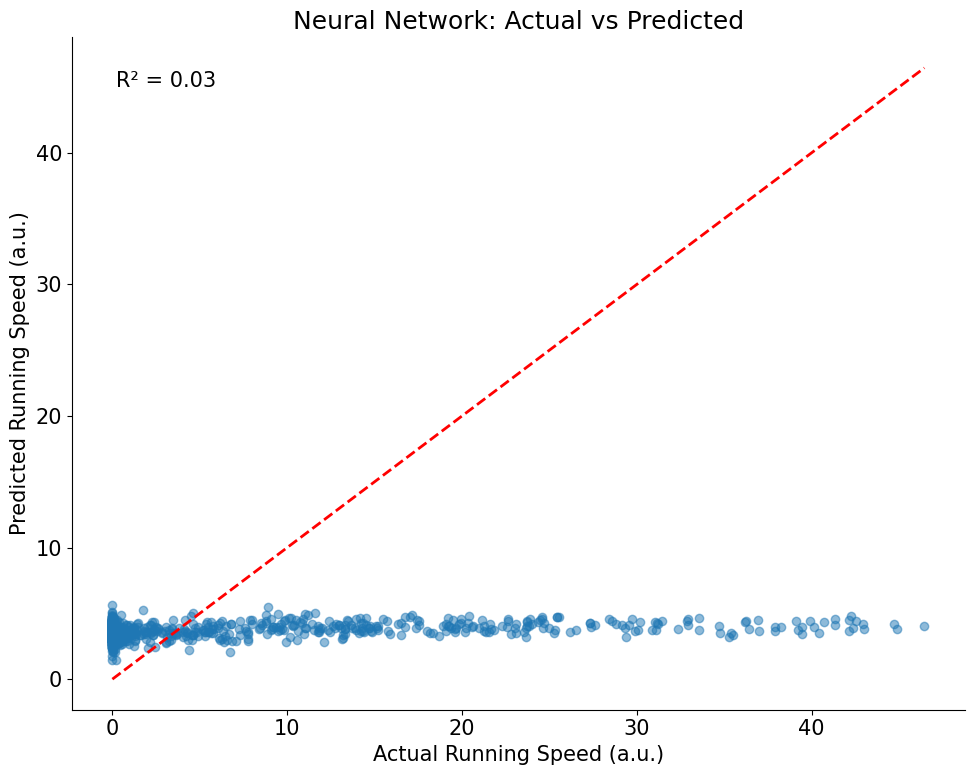

In [ ]:
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Running Speed (a.u.)')
plt.ylabel('Predicted Running Speed (a.u.)')
plt.title('Neural Network: Actual vs Predicted')
plt.text(0.05, 0.95, f'R² = {r2:.2f}', transform=plt.gca().transAxes, verticalalignment='top')
plt.tight_layout()
plt.show()


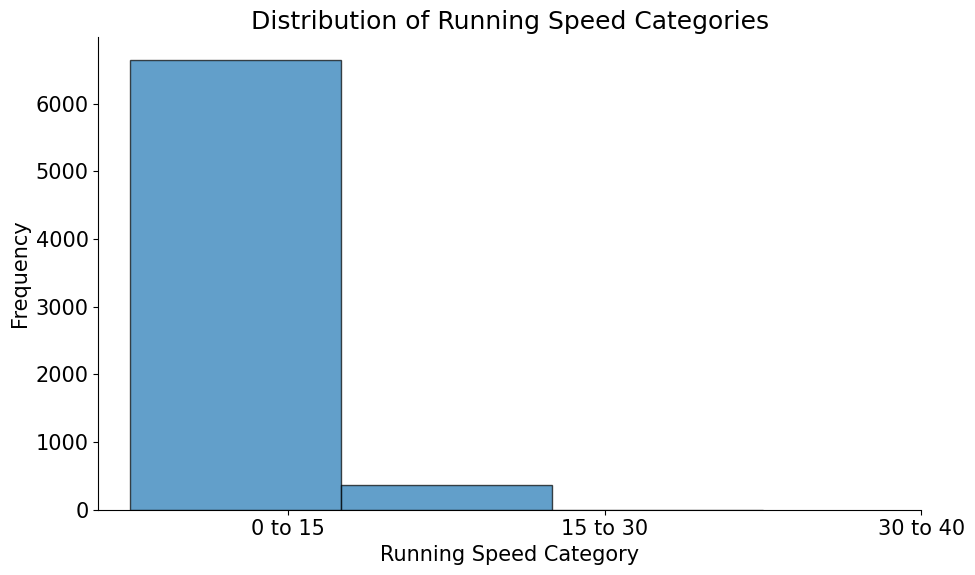

Category Counts: {np.str_('0 to x'): np.int64(6647), np.str_('x to y'): np.int64(370), np.str_('y to z'): np.int64(1)}


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def categorize_running_speeds(run_data, x=15, y=30, z=40):
    """
    Categorizes running speeds into three groups: 0 to x, x to y, and y to z.

    Parameters:
        run_data (np.ndarray): Array of running speeds.
        x (float): First threshold for categorization.
        y (float): Second threshold for categorization.
        z (float): Third threshold for categorization.

    Returns:
        np.ndarray: Array of categorized speeds.
        dict: Dictionary with count of each category.
    """
    # Categorize the running speeds
    categories = np.digitize(run_data, bins=[x, y, z])

    # Map numerical categories to labels for better understanding
    category_labels = np.array(['0 to x', 'x to y', 'y to z'])
    categorized_speeds = category_labels[categories]

    # Count the number of instances in each category
    unique, counts = np.unique(categorized_speeds, return_counts=True)
    category_counts = dict(zip(unique, counts))

    return categorized_speeds, category_counts

# Example usage
run_data = dat['run']  # Replace this with the actual run data
categorized_speeds, category_counts = categorize_running_speeds(run_data, x=25, y=50, z=75)

# Visualize the distribution of categories
plt.figure(figsize=(10, 6))
plt.hist(categorized_speeds, bins=3, edgecolor='black', alpha=0.7)
plt.title('Distribution of Running Speed Categories')
plt.xlabel('Running Speed Category')
plt.ylabel('Frequency')
plt.xticks([0.5, 1.5, 2.5], ['0 to 15', '15 to 30', '30 to 40'])
plt.tight_layout()
plt.show()

# Print category counts
print("Category Counts:", category_counts)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([64, 1, 1])) that is different to the input size (torch.Size([64, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([46, 1, 1])) that is different to the input size (torch.Size([46, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch [10/100], Loss: 1.5658
Epoch [20/100], Loss: 1.1156
Epoch [30/100], Loss: 0.9172
Epoch [40/100], Loss: 0.9242
Epoch [50/100], Loss: 1.0442
Epoch [60/100], Loss: 1.0980
Epoch [70/100], Loss: 1.0837
Epoch [80/100], Loss: 0.7694
Epoch [90/100], Loss: 1.1800
Epoch [100/100], Loss: 1.0884
Neural Network - Mean Squared Error: 1.0000
Neural Network - R-squared Score: -0.0001


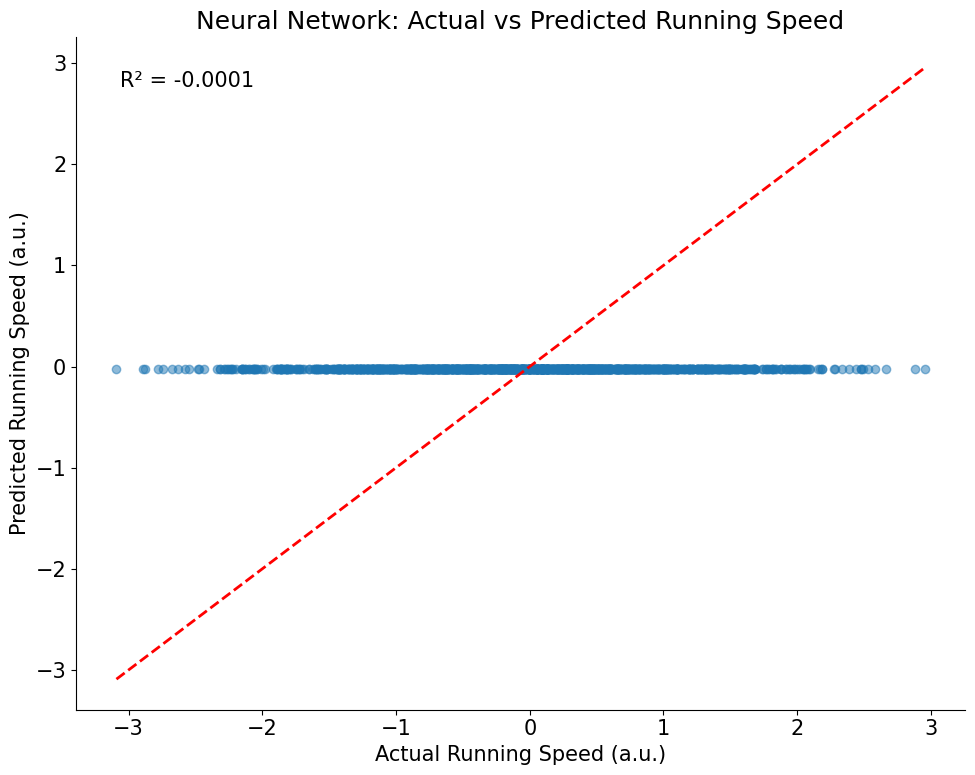

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from scipy.stats import zscore
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Assuming 'dat' is a dictionary containing the data as described
# Replace these lines with actual data loading code
dat = {
    'sresp': np.random.randn(11983, 7018),  # Neural response data
    'run': np.random.randn(7018, 1)  # Running speed data
}

# Extract features and target variable
X = dat['sresp'].T  # Transpose to get timebins x neurons
y = dat['run']

# Normalize input features using Z-scores
X_zscore = zscore(X, axis=0)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_zscore, y, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test).unsqueeze(1)

# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Define the neural network
class NeuralNet(nn.Module):
    def __init__(self, input_size):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, 80)  # Adjusted layer size to approx 80
        self.fc2 = nn.Linear(80, 20)
        self.fc3 = nn.Linear(20, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Initialize the model
model = NeuralNet(X_train.shape[1])

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)  # Adjusted learning rate

# Training loop
num_epochs = 100
for epoch in range(num_epochs):
    for inputs, targets in train_loader:
        outputs = model(inputs)
        loss = criterion(outputs, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# Evaluate the model
model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor).numpy()
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

print(f"Neural Network - Mean Squared Error: {mse:.4f}")
print(f"Neural Network - R-squared Score: {r2:.4f}")

# Plotting
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Running Speed (a.u.)')
plt.ylabel('Predicted Running Speed (a.u.)')
plt.title('Neural Network: Actual vs Predicted Running Speed')
plt.text(0.05, 0.95, f'R² = {r2:.4f}', transform=plt.gca().transAxes, verticalalignment='top')
plt.tight_layout()
plt.show()


Shape of X: (7018, 200)
Shape of y: (7018, 1)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([64, 1, 1])) that is different to the input size (torch.Size([64, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([46, 1, 1])) that is different to the input size (torch.Size([46, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch [10/100], Loss: 0.9076
Epoch [20/100], Loss: 1.0553
Epoch [30/100], Loss: 1.3948
Epoch [40/100], Loss: 1.2369
Epoch [50/100], Loss: 1.2421
Epoch [60/100], Loss: 1.0168
Epoch [70/100], Loss: 0.8211
Epoch [80/100], Loss: 0.9054
Epoch [90/100], Loss: 1.1974
Epoch [100/100], Loss: 0.6400
Neural Network - Mean Squared Error: 1.0234
Neural Network - R-squared Score: -0.0017


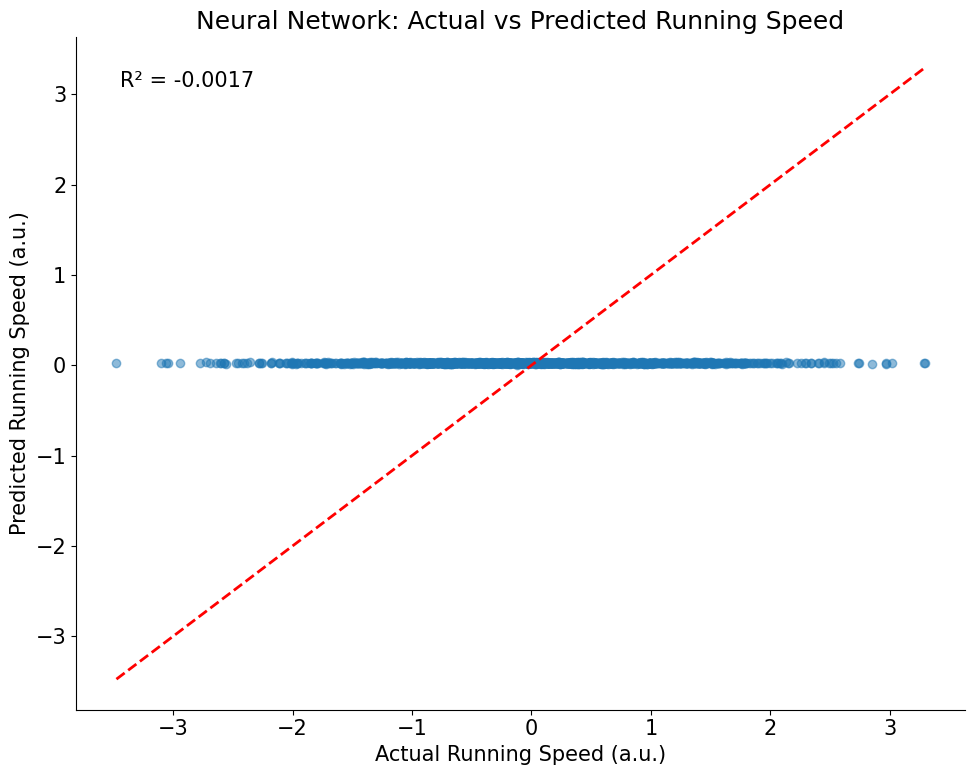

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from scipy.stats import zscore
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Assuming 'dat' is a dictionary containing the data as described
# Replace these lines with actual data loading code
dat = {
    'sresp': np.random.randn(11983, 7018),  # Neural response data
    'run': np.random.randn(7018, 1)  # Running speed data
}

# Normalize and reduce dimensions
Z = zscore(dat['sresp'], axis=1)
Z = np.nan_to_num(Z)
X = PCA(n_components=200).fit_transform(Z.T)  # Ensure transposing to match the number of samples with y

# Extract the target variable
y = dat['run']

# Check the shapes to ensure consistency
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test).unsqueeze(1)

# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Define the neural network
class NeuralNet(nn.Module):
    def __init__(self, input_size):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, 50)  # First hidden layer with 50 neurons
        self.fc2 = nn.Linear(50, 20)  # Second hidden layer with 20 neurons
        self.fc3 = nn.Linear(20, 1)  # Output layer with 1 neuron

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Initialize the model
model = NeuralNet(X_train.shape[1])

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 100
for epoch in range(num_epochs):
    for inputs, targets in train_loader:
        outputs = model(inputs)
        loss = criterion(outputs, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# Evaluate the model
model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor).numpy()
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

print(f"Neural Network - Mean Squared Error: {mse:.4f}")
print(f"Neural Network - R-squared Score: {r2:.4f}")

# Plotting
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Running Speed (a.u.)')
plt.ylabel('Predicted Running Speed (a.u.)')
plt.title('Neural Network: Actual vs Predicted Running Speed')
plt.text(0.05, 0.95, f'R² = {r2:.4f}', transform=plt.gca().transAxes, verticalalignment='top')
plt.tight_layout()
plt.show()


Shape of X: (7018, 200)
Shape of y: (7018, 1)
GLM - Training Mean Squared Error: 0.9708
GLM - Training R-squared Score: 0.0370
GLM - Testing Mean Squared Error: 1.0592
GLM - Testing R-squared Score: -0.0368


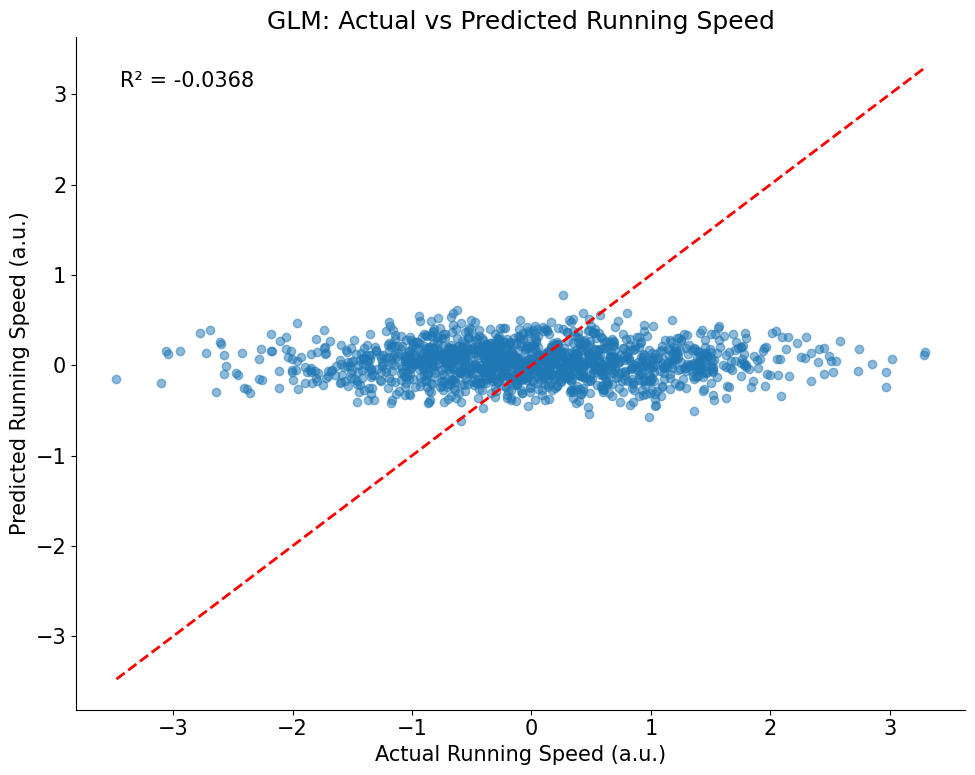

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import zscore
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Normalize and reduce dimensions
Z = zscore(dat['sresp'], axis=1)
Z = np.nan_to_num(Z)
X = PCA(n_components=200).fit_transform(Z.T)  # Ensure transposing to match the number of samples with y

# Extract the target variable
y = dat['run']

# Check the shapes to ensure consistency
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a linear regression model
glm = LinearRegression()
glm.fit(X_train, y_train)

# Make predictions
y_pred_train = glm.predict(X_train)
y_pred_test = glm.predict(X_test)

# Evaluate the model
mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print(f"GLM - Training Mean Squared Error: {mse_train:.4f}")
print(f"GLM - Training R-squared Score: {r2_train:.4f}")
print(f"GLM - Testing Mean Squared Error: {mse_test:.4f}")
print(f"GLM - Testing R-squared Score: {r2_test:.4f}")

# Plotting
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Running Speed (a.u.)')
plt.ylabel('Predicted Running Speed (a.u.)')
plt.title('GLM: Actual vs Predicted Running Speed')
plt.text(0.05, 0.95, f'R² = {r2_test:.4f}', transform=plt.gca().transAxes, verticalalignment='top')
plt.tight_layout()
plt.show()


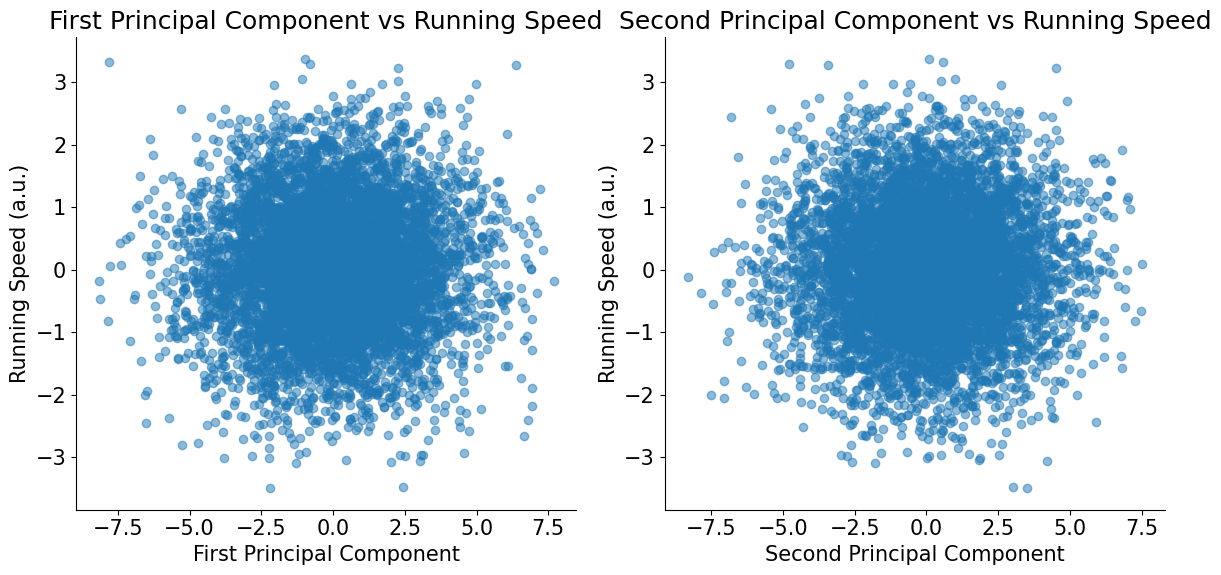

In [ ]:
# Visualize the relationship between the first few principal components and the running speed
plt.figure(figsize=(12, 6))

# First principal component vs running speed
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], y, alpha=0.5)
plt.xlabel('First Principal Component')
plt.ylabel('Running Speed (a.u.)')
plt.title('First Principal Component vs Running Speed')

# Second principal component vs running speed
plt.subplot(1, 2, 2)
plt.scatter(X[:, 1], y, alpha=0.5)
plt.xlabel('Second Principal Component')
plt.ylabel('Running Speed (a.u.)')
plt.title('Second Principal Component vs Running Speed')

plt.tight_layout()
plt.show()

**1. GLM FOR PUPIL AREA**

Mean Squared Error: 31003.39
R-squared: 0.77


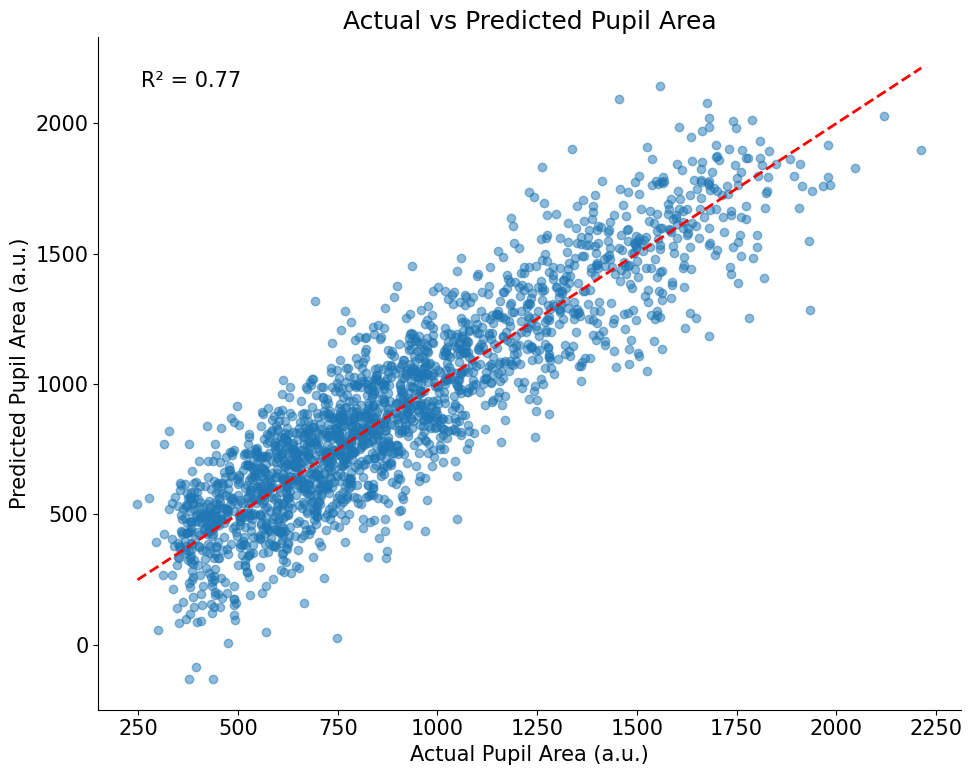

In [ ]:
import numpy as np
# Reload the original dat to ensure all keys are present
dat = np.load('stringer_spontaneous.npy', allow_pickle=True).item()


X = dat['sresp'].T
y= dat['pupilArea']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

# Create the scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.xlabel('Actual Pupil Area (a.u.)')
plt.ylabel('Predicted Pupil Area (a.u.)')
plt.title('Actual vs Predicted Pupil Area')

# Add text for R-squared value
r2 = model.score(X_test, y_test)
plt.text(0.05, 0.95, f'R² = {r2:.2f}', transform=plt.gca().transAxes,
         verticalalignment='top')

plt.tight_layout()
plt.show()

# **1B. GLM FOR PUPIL AREA WITH PCA**

Shape of X: (7018, 200)
Shape of y: (7018, 1)
Mean Squared Error: 16599.87
R-squared: 0.88


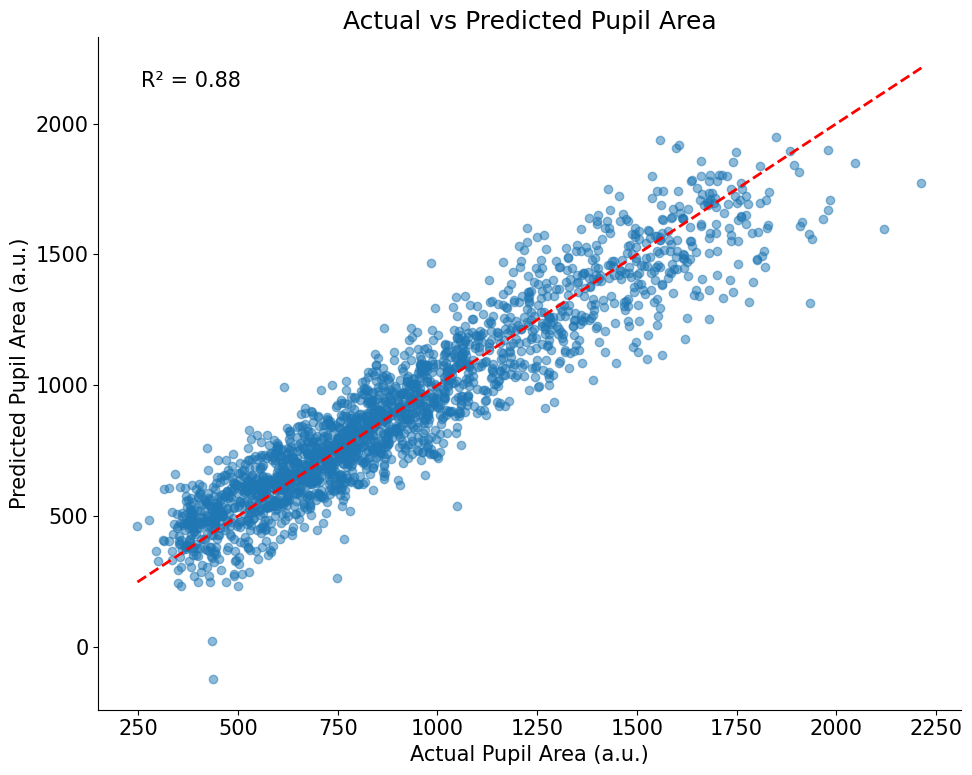

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Normalize and reduce dimensions
Z = zscore(dat['sresp'], axis=1)
Z = np.nan_to_num(Z)
X = PCA(n_components=200).fit_transform(Z.T)  # Ensure transposing to match the number of samples with y

# Extract the target variable
y = dat['pupilArea']

# Check the shapes to ensure consistency
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

# Create the scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.xlabel('Actual Pupil Area (a.u.)')
plt.ylabel('Predicted Pupil Area (a.u.)')
plt.title('Actual vs Predicted Pupil Area')

# Add text for R-squared value
r2 = model.score(X_test, y_test)
plt.text(0.05, 0.95, f'R² = {r2:.2f}', transform=plt.gca().transAxes,
         verticalalignment='top')

plt.tight_layout()
plt.show()


**2. L2 RIDGE PENALTY**

Shape of X: (7018, 200)
Shape of y: (7018, 1)
Mean Squared Error: 1.05
R-squared: -0.04


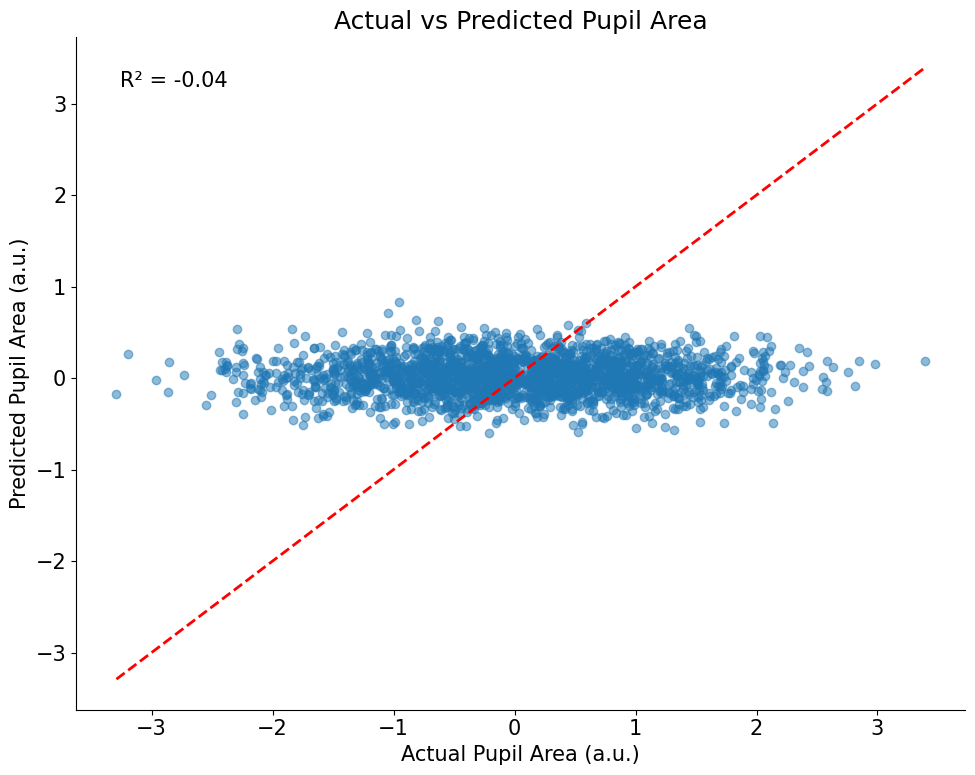

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from scipy.stats import zscore

# Assuming 'dat' is a dictionary containing the data
# Replace these lines with actual data loading code
dat = {
    'sresp': np.random.randn(11983, 7018),  # Neural response data
    'pupilArea': np.random.randn(7018, 1)  # Continuous pupil area data
}

# Normalize and reduce dimensions
Z = zscore(dat['sresp'], axis=1)
Z = np.nan_to_num(Z)
X = PCA(n_components=200).fit_transform(Z.T)  # Ensure transposing to match the number of samples with y

# Extract the target variable
y = dat['pupilArea']

# Check the shapes to ensure consistency
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a Ridge regression model with L2 regularization
ridge_reg = Ridge(alpha=7.0)  # You can adjust the alpha parameter to control the strength of regularization
ridge_reg.fit(X_train, y_train)

# Make predictions
y_pred = ridge_reg.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

# Create the scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.xlabel('Actual Pupil Area (a.u.)')
plt.ylabel('Predicted Pupil Area (a.u.)')
plt.title('Actual vs Predicted Pupil Area')

# Add text for R-squared value
plt.text(0.05, 0.95, f'R² = {r2:.2f}', transform=plt.gca().transAxes, verticalalignment='top')

plt.tight_layout()
plt.show()


Cortical Depth: 150 - 200, R-squared: -0.05
Cortical Depth: 200 - 250, R-squared: -0.03
Cortical Depth: 250 - 300, R-squared: -0.02
Cortical Depth: 300 - 350, R-squared: -0.02
Cortical Depth: 350 - 400, R-squared: -0.02


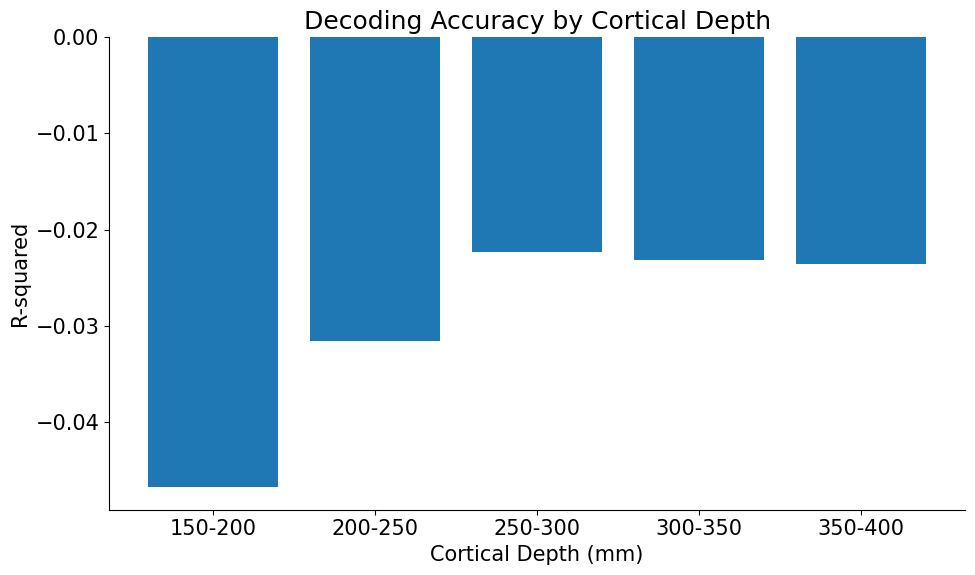

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from scipy.stats import zscore

# Assuming 'dat' is a dictionary containing the data
# Replace these lines with actual data loading code
dat = {
    'sresp': np.random.randn(11983, 7018),  # Neural response data
    'pupilArea': np.random.randn(7018, 1),  # Continuous pupil area data
    'xyz': np.random.rand(11983, 3) * 250 + 150  # 3D positions of each neuron, scaled to range 150-400mm
}

# Define cortical depth bins (adjusted to range 150-400 mm)
depth_bins = [150, 200, 250, 300, 350, 400]  # Adjust these bin edges based on actual depth values

# Extract the target variable
y = dat['pupilArea']

# List to store R² scores for each depth segment
depth_r2_scores = []

# Iterate over cortical depth bins
for i in range(len(depth_bins) - 1):
    # Segment neurons by depth
    depth_mask = (dat['xyz'][:, 2] >= depth_bins[i]) & (dat['xyz'][:, 2] < depth_bins[i + 1])
    X_depth = dat['sresp'][depth_mask, :].T  # Transpose to get timebins x neurons

    if X_depth.shape[1] == 0:
        continue  # Skip if no neurons fall into this depth bin

    # Normalize and reduce dimensions
    Z = zscore(X_depth, axis=1)
    Z = np.nan_to_num(Z)
    X = PCA(n_components=50).fit_transform(Z.T)  # Reduce dimensions to 50 components

    # Filter y to match the timebins in X
    y_filtered = y[:X.shape[0], :]

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y_filtered, test_size=0.3, random_state=42)

    # Train a linear regression model
    linear_reg = LinearRegression()
    linear_reg.fit(X_train, y_train)

    # Make predictions
    y_pred = linear_reg.predict(X_test)

    # Evaluate the model
    r2 = r2_score(y_test, y_pred)
    depth_r2_scores.append(r2)
    print(f"Cortical Depth: {depth_bins[i]} - {depth_bins[i+1]}, R-squared: {r2:.2f}")

# Plot the R² scores for each depth segment
plt.figure(figsize=(10, 6))
plt.bar(range(len(depth_r2_scores)), depth_r2_scores, tick_label=[f"{depth_bins[i]}-{depth_bins[i+1]}" for i in range(len(depth_bins) - 1)])
plt.xlabel('Cortical Depth (mm)')
plt.ylabel('R-squared')
plt.title('Decoding Accuracy by Cortical Depth')
plt.show()
